<a href="https://colab.research.google.com/github/AndroKun/23423043_Andro-Lintang-Mahaegan_UTS-Visi-Komputer/blob/main/Praktek%20paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving crack.jpg to crack (1).jpg
File di folder: ['.config', 'crack (1).jpg', 'crack.jpg', 'sample_data']


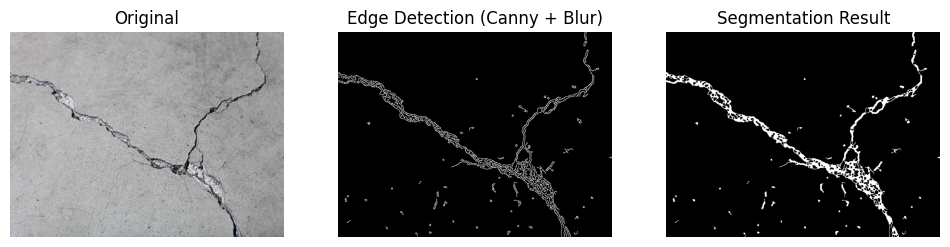

In [3]:
# =========================
# 1. Upload gambar
# =========================
from google.colab import files
uploaded = files.upload()

# =========================
# 2. Import library
# =========================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================
# 3. Cek nama file
# =========================
print("File di folder:", os.listdir())

# Ambil nama file otomatis
filename = list(uploaded.keys())[0]

# =========================
# 4. Load gambar
# =========================
img = cv2.imread(filename)

if img is None:
    print("Gambar gagal dibaca!")
else:
    # Resize
    img = cv2.resize(img, (640, 480))

    # =========================
    # 5. Grayscale + BLUR (BARU)
    # =========================
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur → mengurangi noise
    gray = cv2.GaussianBlur(gray, (5,5), 0)

    # =========================
    # 6. Edge Detection (Canny)
    # =========================
    edges = cv2.Canny(gray, 50, 150)

    # =========================
    # 7. Morphology
    # =========================
    kernel = np.ones((3,3), np.uint8)

    dilation = cv2.dilate(edges, kernel, iterations=1)
    erosion = cv2.erode(dilation, kernel, iterations=1)

    # =========================
    # 8. Threshold (Segmentasi)
    # =========================
    _, thresh = cv2.threshold(erosion, 127, 255, cv2.THRESH_BINARY)

    # =========================
    # 9. Tampilkan hasil
    # =========================
    plt.figure(figsize=(12,6))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Edge Detection (Canny + Blur)")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Segmentation Result")
    plt.imshow(thresh, cmap='gray')
    plt.axis('off')

    plt.show()